# Coordinate Transformations

In this tutorial we will generate data in cylindrical coordinates, rotate the coordinate system, and convert to Cartesian. This relates to these research papers: [Noise Generation Mechanisms in Re-Entrant Backward-Wave Crossed-Field Amplifiers](https://doi.org/10.1109/TED.2025.3608757) and [Spoke Characterization in Re-Entrant Backward Wave Crossed-Field Amplifiers via Simulation](https://doi.org/10.1109/TED.2024.3414379)

## Generate 2D Signal Data
We will generate 2D data that represents a sinusoid rotating azimuthally in phi and in time.

Time  Phi     
0.0   0.000000    1.000000
      0.063467    0.997987
      0.126933    0.991955
      0.190400    0.981929
      0.253866    0.967949
                    ...   
10.0  6.029319    0.967949
      6.092786    0.981929
      6.156252    0.991955
      6.219719    0.997987
      6.283185    1.000000
Name: signal, Length: 100000, dtype: float64


(<Figure size 1200x500 with 2 Axes>,
 <Axes: title={'center': 'signal'}, xlabel='Time ', ylabel='Phi '>,
 <matplotlib.colorbar.Colorbar at 0x7094738639d0>)

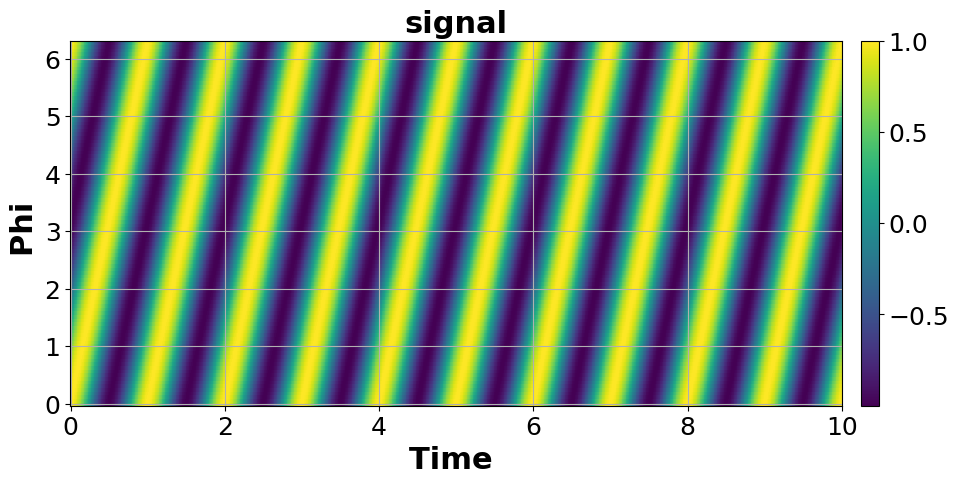

In [9]:
import numpy as np
import pandas as pd
from dmanage.dfmethods import plot


t = np.linspace(0,10,1000)
Nphi = 1
phi = np.linspace(0,2*np.pi,100)
PHI,T = np.meshgrid(phi,t)
data = np.cos(2*np.pi*T - Nphi * PHI)
df = pd.DataFrame(data,columns=phi, index=t)
df.columns.name = 'Phi'
df.index.name = 'Time'
df = df.stack()
df.name = 'signal'
print(df)
plot.pcolor(df)

This represents a wave traveling forward in phi in time. There is only one period in phi. Let's add some amplitude modulate. It's easier to do in a pandas DataFrame then numpy!

(<Figure size 1200x500 with 2 Axes>,
 <Axes: title={'center': 'signal'}, xlabel='Time ', ylabel='Phi '>,
 <matplotlib.colorbar.Colorbar at 0x70946fe27110>)

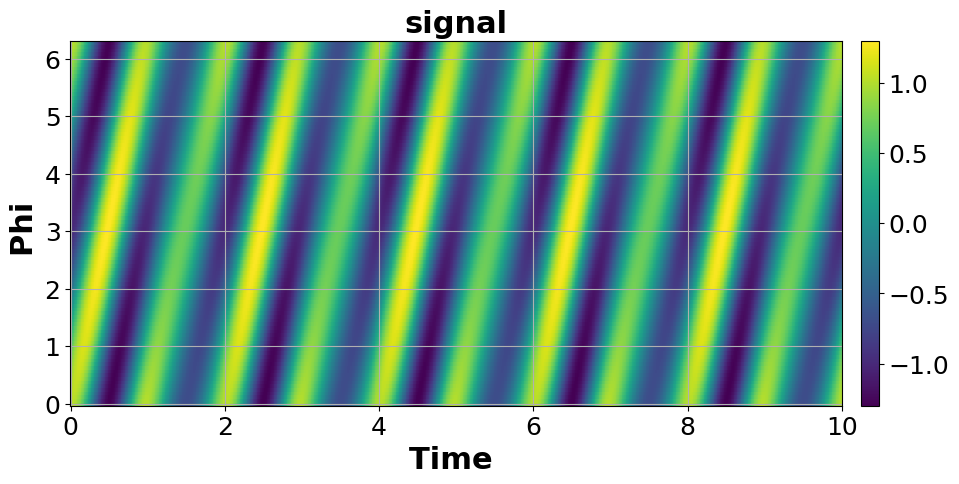

In [10]:
f = 1/2                                   # 0.5 Hz
t = df.index.get_level_values('Time')     # this gets all the time values
phi = df.index.get_level_values('Phi')    # this gets all the phi values
A = 1 + 0.3*np.sin(2*np.pi*f*t)       # amplitude modulation
df1 = df*A.to_numpy()                     # apply the amplitude modulation
plot.pcolor(df1)

## FFT of 2D Signal Data

Let's take the FFT of this! Here we utilize the [dfm.fft.fft](../../../api/dmanage.dfmethods.rst#dmanage.dfmethods.fft.fft), [dfm.fft.fft_amplitude](../../../api/dmanage.dfmethods.rst#dmanage.dfmethods.fft.fft_amplitude), and [dfm.fft.fft_phase](../../../api/dmanage.dfmethods.rst#dmanage.dfmethods.fft.fft_phase) methods.

Phi       Time    
0.000000  0.00000     1.000000
          0.01001     1.007437
          0.02002     1.010806
          0.03003     1.010011
          0.04004     1.004973
                        ...   
6.283185  9.95996     0.932068
          9.96997     0.954493
          9.97998     0.973392
          9.98999     0.988609
          10.00000    1.000000
Name: signal, Length: 100000, dtype: float64


[(0.0, 3.0)]

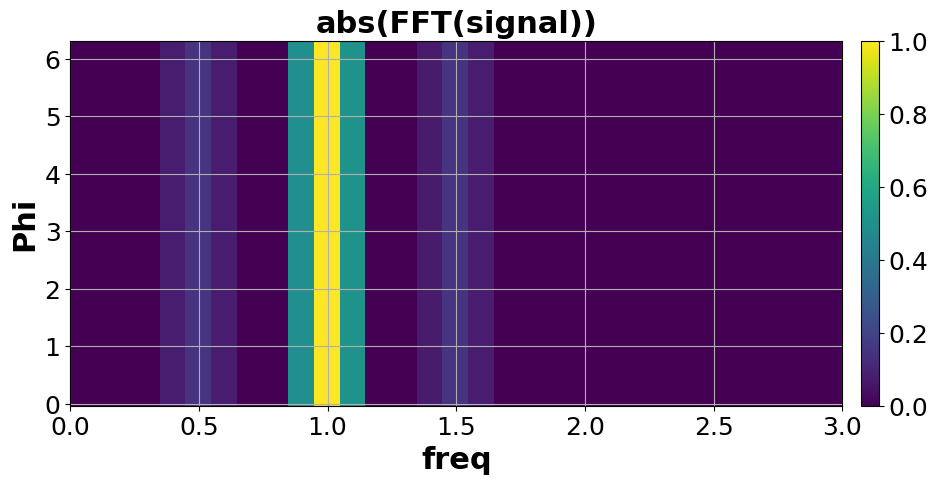

In [11]:
import dmanage.dfmethods as dfm
df2 = df1.reorder_levels(['Phi','Time']).sort_index()
print(df2)
df_fft = dfm.fft.fft(df2)
amplitude = dfm.fft.fft_amplitude(df_fft)
amplitude = amplitude.reorder_levels([1,0]).sort_index()
fig,ax,cbar,_ = plot.pcolor(amplitude,convertAxis=False)
ax.set(xlim=(0,3))

We have a 1 Hz signal, with sidebands located 0.5 Hz away from the peak. This is typical for an amplitude modulated signal with a modulation frequency of 0.5 Hz. Let's check the phase.

[(0.0, 3.0)]

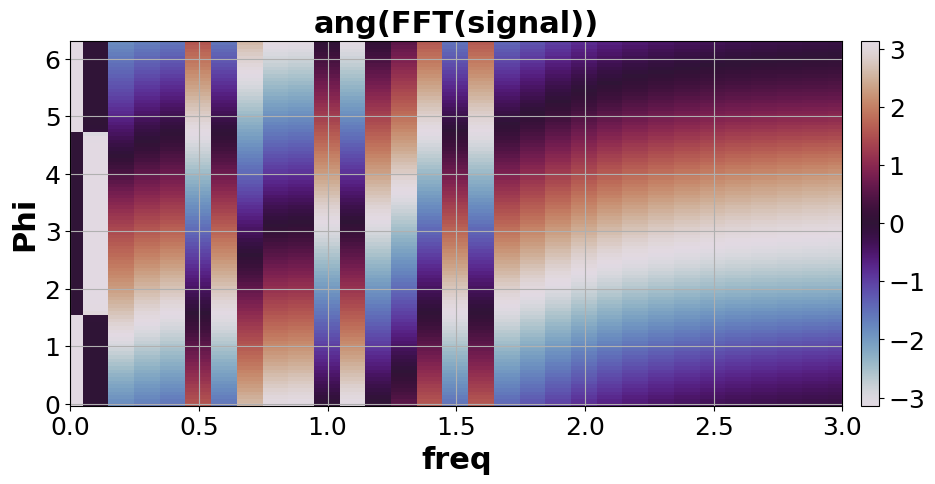

In [12]:
phase = dfm.fft.fft_phase(df_fft)
phase = phase.reorder_levels([1,0]).sort_index()
fig,ax,cbar,_ = plot.pcolor(phase,convertAxis=False,cmap='twilight')
ax.set(xlim=(0,3))

The phase plot is difficult to interpret, but important for my research. Often the most important part is at the relevant frequencies, so I 'cut' the low amplitude portions to help focus on what's important. Let's do that.

[(0.0, 3.0)]

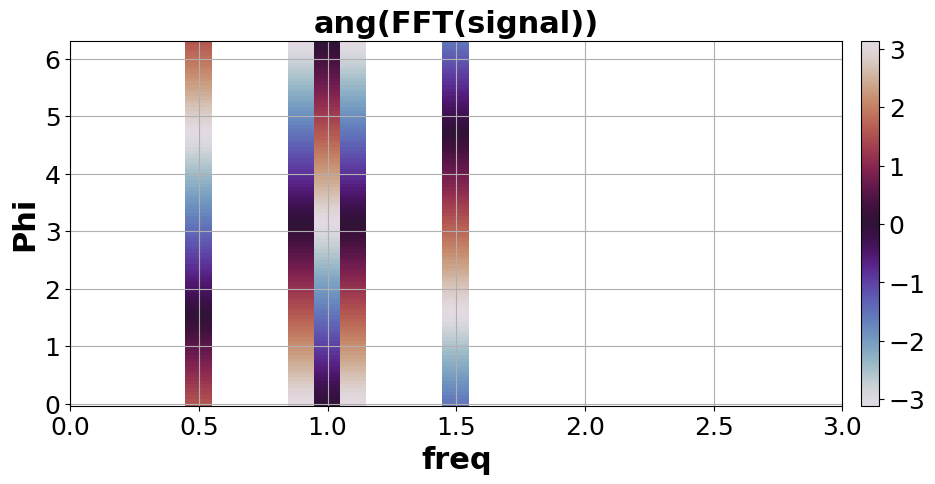

In [13]:
import copy
newPhase = copy.deepcopy(phase)                                 # to preserve phase variable, we deepcopy it
newPhase.iloc[(amplitude<0.1).to_numpy()] = np.nan              # set low amplitude values to not a number
fig,ax,cbar,_ = plot.pcolor(newPhase,convertAxis=False,cmap='twilight')
ax.set(xlim=(0,3))

So only the high amplitude phase values are plotted! At 1 Hz a phase of zero corresponds to a cosine; the cosine starts with a high value at t=0, and the phase is 0 at phi=0.The phase decreases as phi increases.

**_NOTE:_** The phase plot uses a 'twilight' colorbar. This is a cyclic colorbar that is perfect for phase. the phase at + and - pi are equivalent and have the same color! See here for more colorbar options: https://matplotlib.org/stable/users/explain/colors/colormaps.html

The sideband phases are more difficult to interpret in this frame of reference. Let's rotate the data to the frame of reference that follows the wave!

## Rotating Frame of Reference

Here we use the [dfm.convert.rotate_cyl](../../../api/dmanage.dfmethods.rst#dmanage.dfmethods.convert.rotate_cyl) method to convert from the lab frame of reference to the rotating frame of reference that follows the wave. Rotation is simple; all we do is add and angle to phi! However, we need to rotate by an angle that is a function of time. Luckily, we have time in the index and it is 'attached' to our data, so when we rotate, all the data is connected. Also, when we rotate in this way, the phase is 'unraveled', meaning instead of phi going from 0 to 2*pi and connecting back to 0, it goes from 0 to ??. This method 're-ravels' it for you.



(<Figure size 1200x500 with 2 Axes>,
 <Axes: title={'center': 'signal'}, xlabel='Time ', ylabel='Phi '>,
 <matplotlib.colorbar.Colorbar at 0x70946a7ad590>)

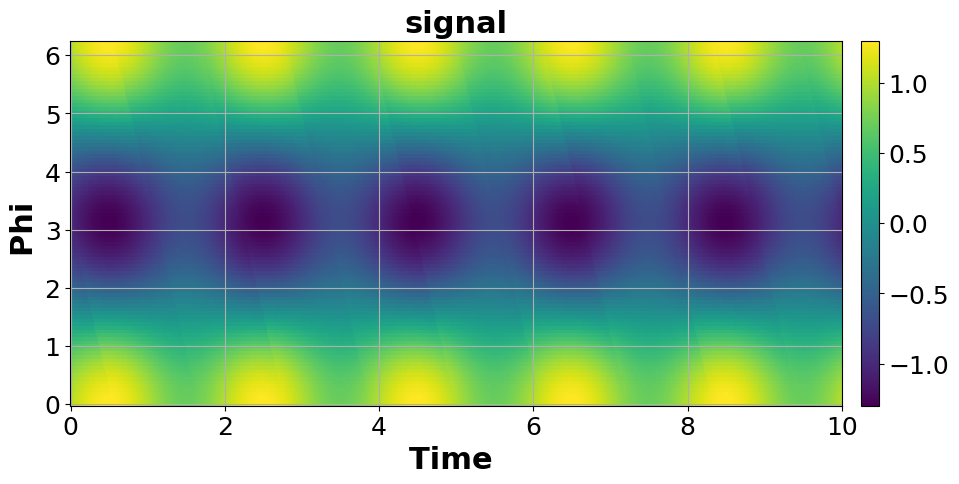

In [14]:
t = df1.index.get_level_values('Time')
theta = -2*np.pi*t/Nphi
df_rot = dfm.convert.rotate_cyl(df1,theta,phiCol='Phi',discretePhi=True)
plot.pcolor(df_rot)

Here we can see that we rotated phi so that the wave is stationary in phi. Now we can see the amplitude modulations through time at 0.5 Hz. We will explore this but first let's take a look at something important!

**_NOTE:_** The `discretePhi` option is very important! This rotates in phi and ensures the same number of unique phi values are in the resulting DataFrame. If `discretePhi= False`, every phi will be unique and makes it difficult to plot! Let's try to plot with `discretePhi=False`


With discretePhi=True, the number of unique phi values is 100
With discretePhi=False, the number of unique phi values is 38665


ValueError: cannot reshape array of size 100000 into shape (1000,38665)

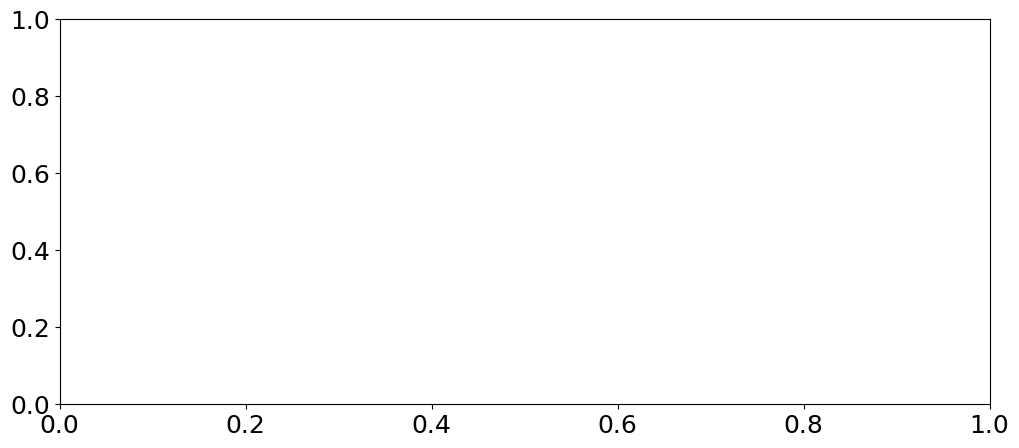

In [15]:
phis = df_rot.index.get_level_values('Phi').unique()
print('With discretePhi=True, the number of unique phi values is %d'%len(phis))
df_rot_bad = dfm.convert.rotate_cyl(df1,theta,phiCol='Phi',discretePhi=False)
phis = df_rot_bad.index.get_level_values('Phi').unique()
print('With discretePhi=False, the number of unique phi values is %d'%len(phis))
plot.pcolor(df_rot_bad)

You cant use plot.pcolor to plot this because it is no longer a uniform grid. `discretePhi` is IMPORTANT! This utilizes `dmanage.dfmethods.convert.make_uniform_df()` method to do this. To Do: I need to explain this method because it's super helpful for things like this.

Now lets take the FFT of the signal in the rotating frame of reference.

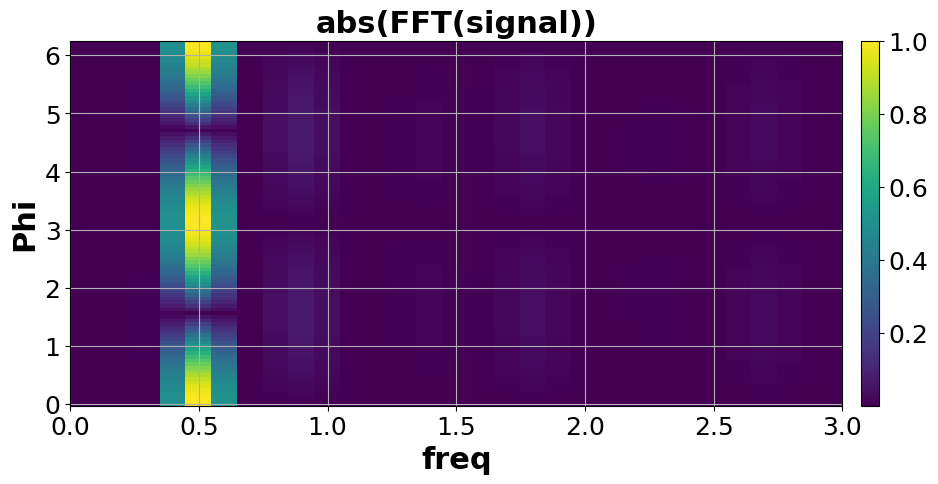

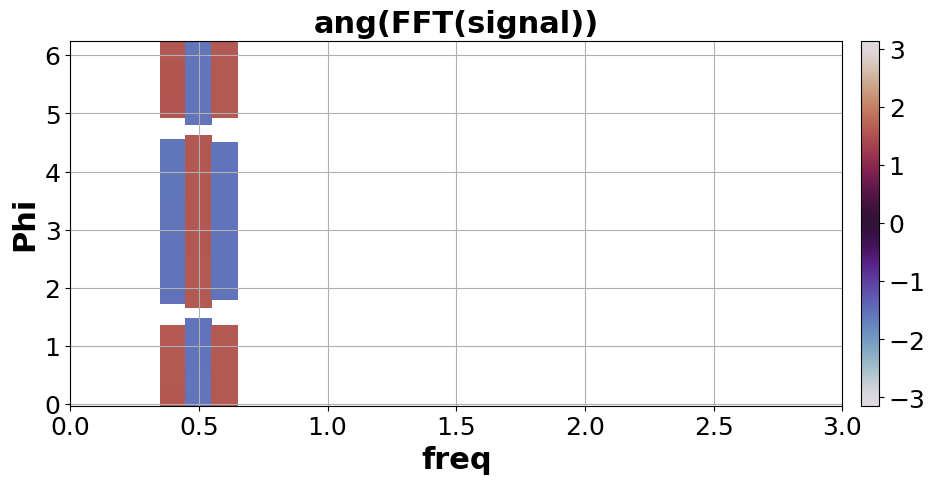

In [67]:
df_rot = df_rot.reorder_levels(['Phi','Time']).sort_index()
df_fft = dfm.fft.fft(df_rot)
amplitude = dfm.fft.fft_amplitude(df_fft)
amplitude = amplitude.reorder_levels([1,0]).sort_index()
phase = dfm.fft.fft_phase(df_fft)
phase = phase.reorder_levels([1,0]).sort_index()
phase.iloc[(amplitude<0.1).to_numpy()] = np.nan              # set low amplitude values to not a number
fig,ax,cbar,_ = plot.pcolor(amplitude,convertAxis=False,fig=1)
ax.set(xlim=(0,3))

fig,ax,cbar,_ = plot.pcolor(phase,convertAxis=False,cmap='twilight',fig=2)
ax.set(xlim=(0,3))
cbar.set_clim(-np.pi, np.pi)

The amplitude modulation is 0.5 Hz! also, the phase is pi/2 at phi=pi, and -pi/2 at phi=0 and phi=2*pi! This is consistent with a sine wave that goes positive first and negative first, respectively. 